In [1]:
!pip install pandas scikit-learn

In [16]:
import pandas as pd

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Load the dataset from CSV
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


# New Section

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
df.drop(columns=['stories' , 'mainroad' , 'guestroom' , 'basement' ,
                 'hotwaterheating', 'airconditioning' ,
                 'prefarea', 'furnishingstatus'] , inplace= True)
df

,price,area,bedrooms,bathrooms,parking
0,13300000,7420,4,2,2
1,12250000,8960,4,4,3
2,12250000,9960,3,2,2
3,12215000,7500,4,2,3
4,11410000,7420,4,1,2
...,...,...,...,...,...
540,1820000,3000,2,1,2
541,1767150,2400,3,1,0
542,1750000,3620,2,1,0
543,1750000,2910,3,1,0


In [ ]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'parking'], dtype='object')


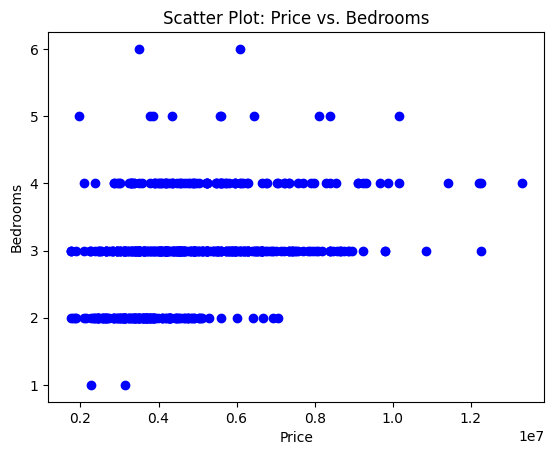

In [ ]:
# Assuming you have a DataFrame named 'df' that contains the columns 'price' and 'bedrooms'
plt.scatter(df['price'], df['bedrooms'], color='blue')  # Blue points for visualization

# Adding labels and title
plt.xlabel("Price")
plt.ylabel("Bedrooms")
plt.title("Scatter Plot: Price vs. Bedrooms")

plt.show()

In [ ]:
X = df[['area', 'bedrooms',]]  # Features: 'area' and 'bedrooms'
y = df['price']               # Target: 'price'


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
# Building the Linear Regression Model
model = LinearRegression()

# Fitting the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Show predicted vs actual values
for i in range(len(y_pred)):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.values[i]}")



Predicted: 5721232.884633073, Actual: 4060000
Predicted: 5259089.655660281, Actual: 6650000
Predicted: 3605915.692485619, Actual: 3710000
Predicted: 4675251.060463285, Actual: 6440000
Predicted: 4270456.301126702, Actual: 2800000
Predicted: 5344719.316289173, Actual: 4900000
Predicted: 6045325.6305255685, Actual: 5250000
Predicted: 5367037.470213562, Actual: 4543000
Predicted: 3294535.1083805547, Actual: 2450000
Predicted: 3780031.881161226, Actual: 3353000
Predicted: 6764357.841385038, Actual: 10150000
Predicted: 3564657.7650916977, Actual: 2660000
Predicted: 3481363.458843593, Actual: 3360000
Predicted: 3935722.173213758, Actual: 3360000
Predicted: 4274348.558428016, Actual: 2275000
Predicted: 4142011.810183363, Actual: 2660000
Predicted: 2811895.203017705, Actual: 2660000
Predicted: 5064476.790594616, Actual: 7350000
Predicted: 5006092.931074916, Actual: 2940000
Predicted: 4368798.123543026, Actual: 2870000
Predicted: 4683035.575065913, Actual: 6720000
Predicted: 5385588.017952964, 

In [ ]:
# Mean Squared Error and R-squared for model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 3280176595474.013
R-squared: 0.3510473817558726


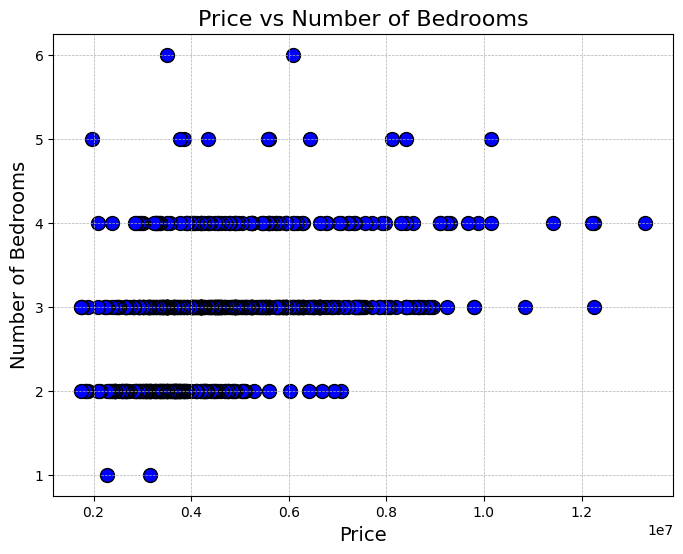

In [ ]:
# Scatter plot: 'price' on x-axis and 'bedrooms' on y-axis
plt.figure(figsize=(8, 6))  # Set the figure size

# Create scatter plot
plt.scatter(df['price'], df['bedrooms'], color='blue', edgecolor='black', s=100)  # Larger points

# Add labels and title
plt.xlabel('Price', fontsize=14)
plt.ylabel('Number of Bedrooms', fontsize=14)
plt.title('Price vs Number of Bedrooms', fontsize=16)

# Add grid lines to enhance visualization
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


# Display the plot
plt.show()

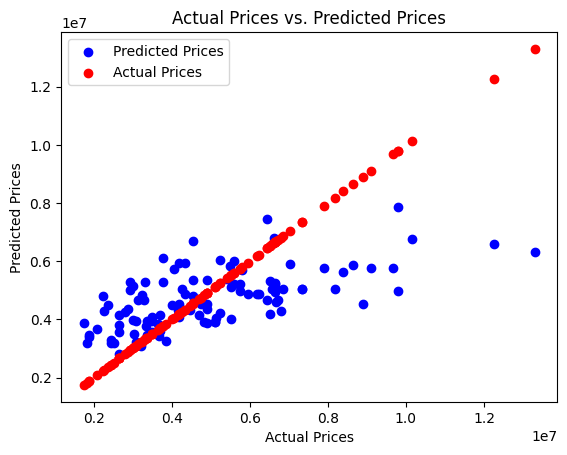

In [ ]:
# Predictions and Visualization
# Scatter plot for actual vs predicted prices with different colors

plt.scatter(y_test, y_pred, color='blue', label='Predicted Prices')  # Predicted prices in blue
plt.scatter(y_test, y_test, color='red', label='Actual Prices')  # Actual prices in red (diagonal)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.legend()  # To show the legend for the color labels
plt.show()








In [ ]:
# Example: Predict price for a new house with area and bedrooms
new_data = pd.DataFrame({
    'area': [8500],
    'bedrooms': [4]
})

predicted_price = model.predict(new_data)
print(f"Predicted price: {predicted_price[0]}")

Predicted price: 6733219.782974531
